<a href="https://colab.research.google.com/github/lizzietsitsishvili/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2016/%5BLab_16%5D_Regularization_%E2%80%94_Lasso_%26_Ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
!pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [3]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [6]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================
# Average all indicators across the 2013-2019 period per country
# This gives us one observation per country — a cross-sectional dataset

# Average over time dimension (across year columns for each (economy, indicator) pair)
# raw_data has MultiIndex (economy, series) and columns YR2013...YR2019
raw_data_avg_years = raw_data.mean(axis=1) # Average across years for each (economy, series)

# Unstack the series level to make indicators into columns
country_data = raw_data_avg_years.unstack(level='series')

# Rename columns to human-readable names
country_data = country_data.rename(columns=INDICATORS)

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [7]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [8]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================
# OLS will overfit when p/n is large. We predict this BEFORE looking at results.
# Prediction: high training R², but much lower (possibly negative) test R².

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [10]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================
# YOUR TASK: Complete the RidgeCV fit below.
# RidgeCV tries all alphas in the list and picks the one with
# lowest cross-validation error.
#
# Note: sklearn calls λ "alpha" for historical reasons.

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [11]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

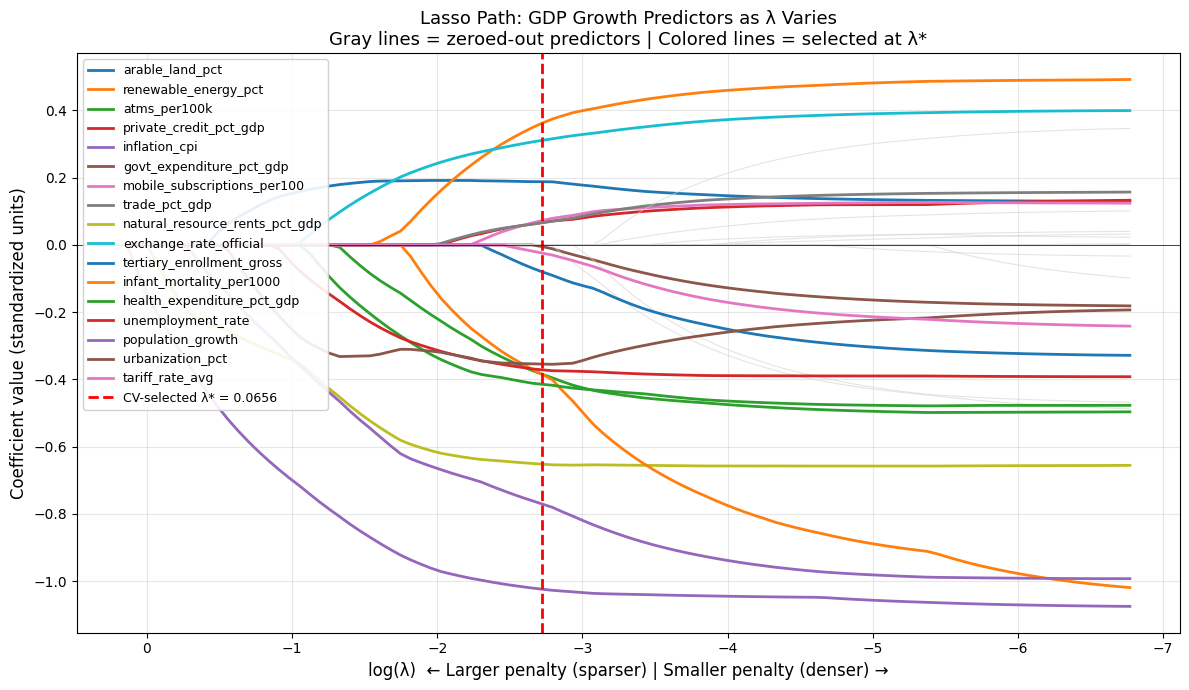

Lasso Path saved to lasso_path_gdp_growth.png
First variable to enter the model: inflation_cpi
Lambda where it first enters:      1.0693

Variables selected at CV-optimal λ*:
arable_land_pct                          coef = +0.1881
renewable_energy_pct                     coef = +0.3627
atms_per100k                             coef = -0.3850
private_credit_pct_gdp                   coef = +0.0669
inflation_cpi                            coef = -1.0240
govt_expenditure_pct_gdp                 coef = -0.0052
mobile_subscriptions_per100              coef = +0.0729
trade_pct_gdp                            coef = +0.0661
natural_resource_rents_pct_gdp           coef = -0.6521
exchange_rate_official                   coef = +0.3112
tertiary_enrollment_gross                coef = -0.0797
infant_mortality_per1000                 coef = -0.3856
health_expenditure_pct_gdp               coef = -0.4145
unemployment_rate                        coef = -0.3716
population_growth                        

In [12]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================

# Compute the Lasso path using the LARS algorithm
# Returns:
#   alphas_path : sequence of lambda values
#   coefs_path  : coefficient values for each feature at each lambda
#   _           : dual gaps (not used here)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_train,
    eps=1e-3,
    n_alphas=100
)

# CV-selected lambda from Part 2B
optimal_alpha = lasso_cv_model.alpha_

# Features that remain active (non-zero) at the CV-optimal lambda
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

# ------------------------------------------------------------
# Identify the first variable to enter the model
# ------------------------------------------------------------
first_enter_idx = None
first_enter_alpha = None

for j in range(coefs_path.shape[1]):
    nonzero_now = np.where(np.abs(coefs_path[:, j]) > 1e-8)[0]
    if len(nonzero_now) > 0:
        first_enter_idx = nonzero_now[0]
        first_enter_alpha = alphas_path[j]
        break

# ------------------------------------------------------------
# Plot the Lasso path
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(
            np.log(alphas_path),
            coefs_path[i],
            linewidth=2,
            label=feature_names[i]
        )
    else:
        ax.plot(
            np.log(alphas_path),
            coefs_path[i],
            linewidth=0.8,
            color='lightgray',
            alpha=0.6
        )

# Mark CV-selected lambda
ax.axvline(
    np.log(optimal_alpha),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'CV-selected λ* = {optimal_alpha:.4f}'
)

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel(
    'log(λ)  ← Larger penalty (sparser) | Smaller penalty (denser) →',
    fontsize=12
)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)

ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Lasso Path saved to lasso_path_gdp_growth.png")

# ------------------------------------------------------------
# Print interpretation helpers
# ------------------------------------------------------------
if first_enter_idx is not None:
    print(f"First variable to enter the model: {feature_names[first_enter_idx]}")
    print(f"Lambda where it first enters:      {first_enter_alpha:.4f}")

print("\nVariables selected at CV-optimal λ*:")
for i in active_features_idx:
    print(f"{feature_names[i]:<40} coef = {lasso_cv_model.coef_[i]:+.4f}")

In [14]:
# ============================================================
# EXTENSION: What if we change the outcome? (optional, ~5 min)
# ============================================================

# Choose a different outcome
EXTENSION_OUTCOME = 'infant_mortality_per1000'
# Other options:
# EXTENSION_OUTCOME = 'urbanization_pct'
# EXTENSION_OUTCOME = 'secondary_enrollment_gross'

# ------------------------------------------------------------
# 1. Define X and new y
# ------------------------------------------------------------
X_ext = country_data[feature_names]
y_ext = country_data[EXTENSION_OUTCOME]

# ------------------------------------------------------------
# 2. Train/test split
# Use the same split settings as before
# ------------------------------------------------------------
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. Standardize predictors using training data only
# ------------------------------------------------------------
scaler_ext = StandardScaler()
X_train_ext_scaled = scaler_ext.fit_transform(X_train_ext)
X_test_ext_scaled  = scaler_ext.transform(X_test_ext)

# ------------------------------------------------------------
# 4. Fit LassoCV
# ------------------------------------------------------------
lasso_ext = LassoCV(cv=5, max_iter=10_000, random_state=42)
lasso_ext.fit(X_train_ext_scaled, y_train_ext)

# ------------------------------------------------------------
# 5. Predict and evaluate
# ------------------------------------------------------------
y_pred_ext = lasso_ext.predict(X_test_ext_scaled)

ext_test_r2  = r2_score(y_test_ext, y_pred_ext)
ext_test_mse = mean_squared_error(y_test_ext, y_pred_ext)

# ------------------------------------------------------------
# 6. Summarize selected predictors
# ------------------------------------------------------------
n_nonzero_ext = np.sum(lasso_ext.coef_ != 0)

print("=" * 55)
print(f"LASSO EXTENSION RESULTS: {EXTENSION_OUTCOME}")
print("=" * 55)
print(f"Optimal λ* (CV-selected): {lasso_ext.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero_ext} of {X_ext.shape[1]}")
print(f"Test R²:                  {ext_test_r2:.3f}")
print(f"Test MSE:                 {ext_test_mse:.3f}")
print()

print("Selected predictors (non-zero coefficients):")
selected_ext = [
    (feature_names[i], lasso_ext.coef_[i])
    for i in range(len(feature_names))
    if lasso_ext.coef_[i] != 0
]

for name, coef in sorted(selected_ext, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO EXTENSION RESULTS: infant_mortality_per1000
Optimal λ* (CV-selected): 0.0336
Non-zero coefficients:    1 of 28
Test R²:                  1.000
Test MSE:                 0.001

Selected predictors (non-zero coefficients):
  infant_mortality_per1000                 coef = +33.5996


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.9 MB/s eta 0:00:00


2026-04-02 01:07:18.575 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 01:07:18.576 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 01:07:18.678 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-02 01:07:18.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 01:07:18.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 01:07:18.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 01:07:18.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

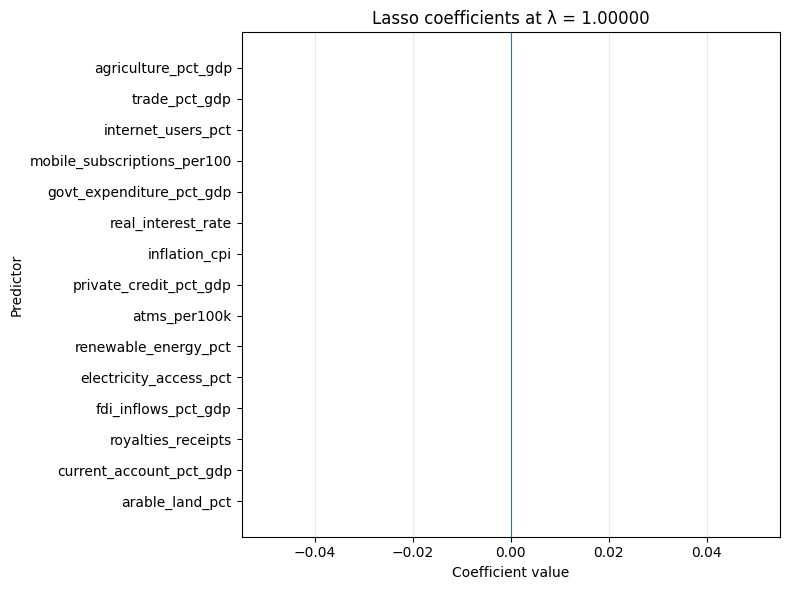

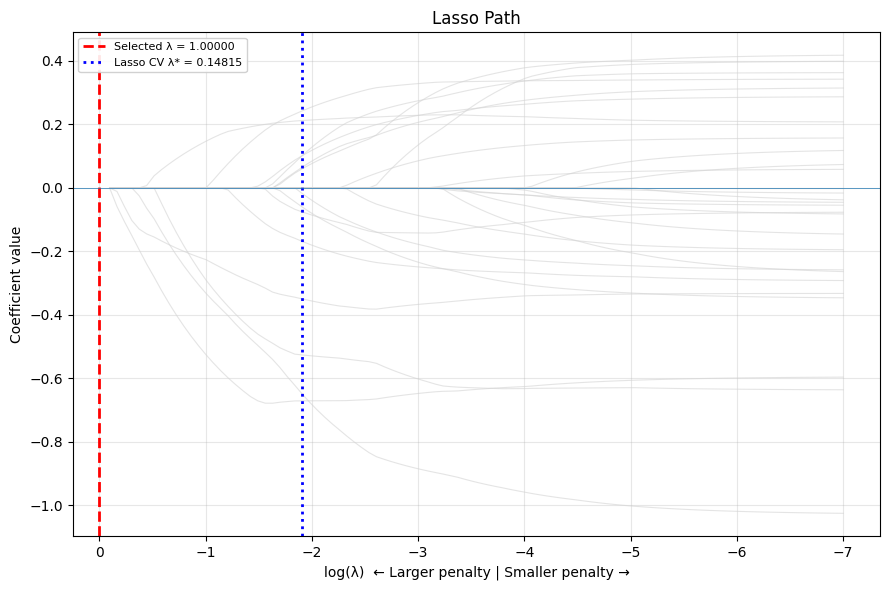

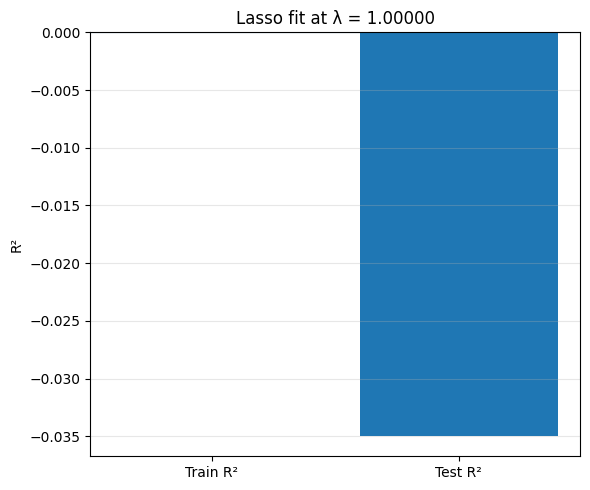

In [16]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, lasso_path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# ============================================================
# STREAMLIT PAGE SETUP
# ============================================================
st.set_page_config(
    page_title="Interactive Regularization Explorer",
    layout="wide"
)

st.title("Interactive Regularization Explorer")
st.markdown(
    """
    Explore how **Ridge** and **Lasso** regularization change coefficient estimates,
    model sparsity, and out-of-sample performance on World Development Indicators.
    """
)

# ============================================================
# ASSUMPTION: country_data already exists in your environment
# ============================================================
# This app assumes your notebook already created:
#   - country_data      : DataFrame with one row per country
#   - feature_names     : list of predictor column names
#   - OUTCOME_VAR       : default outcome variable name
#
# If you want this to be fully standalone, replace the next block
# with your WDI download / construction code.

required_objects = ["country_data", "feature_names", "OUTCOME_VAR"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    st.error(
        f"Missing required objects in memory: {missing_objects}\n\n"
        "This Streamlit app expects `country_data`, `feature_names`, and "
        "`OUTCOME_VAR` to already exist. If you want a standalone app, paste "
        "your data construction code above this section."
    )
    st.stop()

# Work on a copy
df = country_data.copy()

# ============================================================
# OUTCOME OPTIONS
# ============================================================
# We include the default outcome plus a few additional development outcomes
# that may exist in your dataset. Only variables present in df are used.

candidate_outcomes = [
    OUTCOME_VAR,
    "gdp_growth",
    "infant_mortality_per1000",
    "urbanization_pct",
    "secondary_enrollment_gross"
]

available_outcomes = [col for col in candidate_outcomes if col in df.columns]
available_outcomes = list(dict.fromkeys(available_outcomes))  # remove duplicates

if len(available_outcomes) == 0:
    st.error("No valid outcome variables were found in `country_data`.")
    st.stop()

# ============================================================
# SIDEBAR CONTROLS
# ============================================================
st.sidebar.header("Model Controls")

selected_model = st.sidebar.selectbox(
    "Choose regularization model",
    options=["Lasso", "Ridge"]
)

selected_outcome = st.sidebar.selectbox(
    "Choose outcome variable",
    options=available_outcomes,
    index=available_outcomes.index(OUTCOME_VAR) if OUTCOME_VAR in available_outcomes else 0
)

test_size = st.sidebar.slider(
    "Test set proportion",
    min_value=0.10,
    max_value=0.40,
    value=0.20,
    step=0.05
)

# Lambda slider: log-scale feel using powers of 10
log_lambda = st.sidebar.slider(
    "log10(λ)",
    min_value=-3.0,
    max_value=3.0,
    value=0.0,
    step=0.1
)
selected_lambda = 10 ** log_lambda

st.sidebar.markdown(f"**Selected λ:** {selected_lambda:.5f}")

random_seed = st.sidebar.number_input(
    "Random seed",
    min_value=0,
    max_value=9999,
    value=42,
    step=1
)

# ============================================================
# PREPARE DATA
# ============================================================
# Keep only rows with non-missing values in chosen outcome and predictors
model_cols = feature_names + [selected_outcome]
df_model = df[model_cols].dropna().copy()

X = df_model[feature_names]
y = df_model[selected_outcome]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_seed
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# FIT MODEL FOR CURRENT SLIDER VALUE
# ============================================================
# Every time the user moves st.slider(), Streamlit reruns the script from top
# to bottom. That means this block refits the selected Ridge/Lasso model at
# the NEW lambda automatically, creating the real-time interactivity.

if selected_model == "Lasso":
    model = Lasso(alpha=selected_lambda, max_iter=10_000, random_state=42)
else:
    model = Ridge(alpha=selected_lambda, random_state=42)

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

coef_series = pd.Series(model.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)

# ============================================================
# COMPUTE CV-OPTIMAL MODELS FOR REFERENCE
# ============================================================
# These are useful benchmarks for the user.
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_cv.fit(X_train_scaled, y_train)

lasso_cv = LassoCV(cv=5, max_iter=10_000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

if selected_model == "Lasso":
    cv_optimal_alpha = lasso_cv.alpha_
else:
    cv_optimal_alpha = ridge_cv.alpha_

# ============================================================
# CACHE LASSO PATH
# ============================================================
# lasso_path can be computationally expensive. Since the path depends only on
# the training data and outcome—not on the slider—we cache it so Streamlit
# does NOT recompute the full path every time the user nudges λ.
#
# The vertical line in the plot will still update instantly because only the
# plotting layer changes when the slider value changes.

@st.cache_data
def compute_lasso_path_cached(X_train_scaled_arr, y_train_arr):
    alphas_path, coefs_path, _ = lasso_path(
        X_train_scaled_arr,
        y_train_arr,
        eps=1e-3,
        n_alphas=100
    )
    return alphas_path, coefs_path

lasso_alphas_path, lasso_coefs_path = compute_lasso_path_cached(
    X_train_scaled,
    np.asarray(y_train)
)

# ============================================================
# SUMMARY METRICS
# ============================================================
col_m1, col_m2, col_m3, col_m4 = st.columns(4)
col_m1.metric("Outcome", selected_outcome)
col_m2.metric("Model", selected_model)
col_m3.metric("Train R²", f"{train_r2:.3f}")
col_m4.metric("Test R²", f"{test_r2:.3f}")

st.markdown(
    f"""
    **Selected λ:** {selected_lambda:.5f}
    **CV-optimal λ for {selected_model}:** {cv_optimal_alpha:.5f}
    **Non-zero coefficients:** {np.sum(model.coef_ != 0)} of {len(feature_names)}
    """
)

# ============================================================
# PANEL LAYOUT
# ============================================================
panel1, panel2, panel3 = st.columns([1.1, 1.2, 0.9])

# ------------------------------------------------------------
# PANEL 1: COEFFICIENT BAR CHART
# ------------------------------------------------------------
with panel1:
    st.subheader("1) Coefficient Bar Chart")

    top_k = st.slider(
        "Number of coefficients to display",
        min_value=5,
        max_value=min(25, len(feature_names)),
        value=min(15, len(feature_names)),
        step=1
    )

    coef_display = coef_series.head(top_k).sort_values()

    fig1, ax1 = plt.subplots(figsize=(8, 6))
    ax1.barh(coef_display.index, coef_display.values)
    ax1.set_xlabel("Coefficient value")
    ax1.set_ylabel("Predictor")
    ax1.set_title(f"{selected_model} coefficients at λ = {selected_lambda:.5f}")
    ax1.axvline(0, linewidth=0.8)
    ax1.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig1)

# ------------------------------------------------------------
# PANEL 2: LASSO PATH
# ------------------------------------------------------------
with panel2:
    st.subheader("2) Lasso Path")

    fig2, ax2 = plt.subplots(figsize=(9, 6))

    # For Ridge, we still show the Lasso path as a feature-selection map
    # because Ridge does not produce exact-zero paths in the same way.
    active_features_idx = np.where(np.abs(model.coef_) > 1e-8)[0]

    for i in range(len(feature_names)):
        if i in active_features_idx:
            ax2.plot(
                np.log(lasso_alphas_path),
                lasso_coefs_path[i],
                linewidth=2,
                label=feature_names[i]
            )
        else:
            ax2.plot(
                np.log(lasso_alphas_path),
                lasso_coefs_path[i],
                linewidth=0.8,
                color="lightgray",
                alpha=0.6
            )

    # This vertical line updates because its x-position is tied directly
    # to the current slider-selected lambda.
    ax2.axvline(
        np.log(selected_lambda),
        linestyle="--",
        linewidth=2,
        color="red",
        label=f"Selected λ = {selected_lambda:.5f}"
    )

    ax2.axvline(
        np.log(lasso_cv.alpha_),
        linestyle=":",
        linewidth=2,
        color="blue",
        label=f"Lasso CV λ* = {lasso_cv.alpha_:.5f}"
    )

    ax2.axhline(0, linewidth=0.5)
    ax2.set_xlabel("log(λ)  ← Larger penalty | Smaller penalty →")
    ax2.set_ylabel("Coefficient value")
    ax2.set_title("Lasso Path")
    ax2.invert_xaxis()
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper left", fontsize=8, framealpha=0.9)
    plt.tight_layout()
    st.pyplot(fig2)

# ------------------------------------------------------------
# PANEL 3: TRAIN VS TEST R²
# ------------------------------------------------------------
with panel3:
    st.subheader("3) Train–Test R² Comparison")

    fig3, ax3 = plt.subplots(figsize=(6, 5))
    ax3.bar(["Train R²", "Test R²"], [train_r2, test_r2])
    ax3.set_ylabel("R²")
    ax3.set_title(f"{selected_model} fit at λ = {selected_lambda:.5f}")
    ax3.axhline(0, linewidth=0.8)
    ax3.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig3)

    st.write(f"**Train–Test Gap:** {train_r2 - test_r2:+.3f}")

# ============================================================
# SELECTED FEATURES TABLE
# ============================================================
st.subheader("Selected / Estimated Coefficients")

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_,
    "abs_coefficient": np.abs(model.coef_)
}).sort_values("abs_coefficient", ascending=False)

st.dataframe(coef_table, use_container_width=True)

# ============================================================
# INTERPRETATION GUIDE
# ============================================================
st.subheader("How to Interpret the Dashboard")

st.markdown(
    """
    - **Very high λ:** the penalty is strong, so coefficients are heavily shrunk toward zero.
      For **Lasso**, many may become exactly zero. This creates a very simple model, but it may underfit.

    - **Very low λ:** the penalty becomes weak, so the model approaches **OLS-like flexibility**.
      Coefficients can become larger and the model may fit the training data very well, but test performance can suffer if the model overfits.

    - **CV-optimal λ:** this is the penalty chosen by cross-validation as the best tradeoff between bias and variance on the training folds.
      It is often the most defensible practical choice.

    - **Why train and test R² diverge at extreme λ values:**
      At **very low λ**, the model can overfit noise, so **train R² rises** while **test R² falls**.
      At **very high λ**, the model can become too constrained, so both train and test R² may fall because the model underfits.

    - **General vs. specific predictors:**
      If the same predictors stay important across multiple outcomes, they may be broad development indicators.
      If selected predictors change a lot when you switch outcomes, that suggests the drivers are more outcome-specific.
    """
)